In [1]:
import torch 
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

In [2]:
from pathlib import Path

DATA_DIR = Path(r"../datasets/Apple")

TRAIN_DIR = DATA_DIR / "Training"
VAL_DIR = DATA_DIR / "Validation"
TEST_DIR = DATA_DIR / "Test"

print("Training:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Training: ..\datasets\Apple\Training
Validation: ..\datasets\Apple\Validation
Test: ..\datasets\Apple\Test


In [3]:
train_ds = datasets.ImageFolder(TRAIN_DIR)
val_ds = datasets.ImageFolder(VAL_DIR)
test_ds = datasets.ImageFolder(TEST_DIR)

In [8]:
print("Training images:", len(train_ds))
print("Validation images:", len(val_ds))
print("Test images:", len(test_ds))

Training images: 11028
Validation images: 5515
Test images: 5492


In [9]:
print(len(train_ds.classes), "classes:", train_ds.classes)

30 classes: ['Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20', 'Apple 21', 'Apple 22', 'Apple 23', 'Apple 5', 'Apple 6', 'Apple 7', 'Apple 8', 'Apple 9', 'Apple Braeburn 1', 'Apple Red Yellow 2', 'apple_crimson_snow_1', 'apple_golden_1', 'apple_golden_2', 'apple_golden_3', 'apple_granny_smith_1', 'apple_pink_lady_1', 'apple_red_1', 'apple_red_2', 'apple_red_3', 'apple_red_delicios_1', 'apple_red_yellow_1']


In [11]:
print(train_ds.class_to_idx)

{'Apple 10': 0, 'Apple 11': 1, 'Apple 12': 2, 'Apple 13': 3, 'Apple 14': 4, 'Apple 17': 5, 'Apple 18': 6, 'Apple 19': 7, 'Apple 20': 8, 'Apple 21': 9, 'Apple 22': 10, 'Apple 23': 11, 'Apple 5': 12, 'Apple 6': 13, 'Apple 7': 14, 'Apple 8': 15, 'Apple 9': 16, 'Apple Braeburn 1': 17, 'Apple Red Yellow 2': 18, 'apple_crimson_snow_1': 19, 'apple_golden_1': 20, 'apple_golden_2': 21, 'apple_golden_3': 22, 'apple_granny_smith_1': 23, 'apple_pink_lady_1': 24, 'apple_red_1': 25, 'apple_red_2': 26, 'apple_red_3': 27, 'apple_red_delicios_1': 28, 'apple_red_yellow_1': 29}


In [4]:
img, label = train_ds[0]

print("Image type:", type(img))
print("Image shape:", img.size)
print("Label value:", label)


Image type: <class 'PIL.Image.Image'>
Image shape: (447, 399)
Label value: 0


In [15]:
print("Class:", train_ds.classes[label])

Class: Apple 10


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [6]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

In [7]:
image, label = train_ds[0]

print("Type:", type(image))
print("Shape:", image.shape)
print("Label:", label)
print("Min:", image.min().item())
print("Max:", image.max().item())

Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Label: 0
Min: 0.0
Max: 1.0


In [8]:
BACTH_SIZE = 32

train_loader = DataLoader(
    train_ds, 
    batch_size=BACTH_SIZE, 
    shuffle=True)

val_loader = DataLoader(
    val_ds, 
    batch_size=BACTH_SIZE, 
    shuffle=False)

test_loader = DataLoader(
    test_ds,
    batch_size=BACTH_SIZE,
    shuffle=False)

In [9]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([15,  4, 22,  8, 18,  5, 17, 28, 16,  2,  3, 28,  8, 10, 23,  1,  8,  0,
        22, 20, 15,  7,  6, 12,  0,  7, 15, 17, 25, 20, 11, 21])


In [22]:
print(labels[:10])

tensor([ 5,  1,  4,  2,  5, 12,  2,  2, 22, 15])


In [10]:
for i in range(10):
    print(
        f"Label {labels[i].item()} → "
        f"{train_ds.classes[labels[i].item()]}"
    )

Label 15 → Apple 8
Label 4 → Apple 14
Label 22 → apple_golden_3
Label 8 → Apple 20
Label 18 → Apple Red Yellow 2
Label 5 → Apple 17
Label 17 → Apple Braeburn 1
Label 28 → apple_red_delicios_1
Label 16 → Apple 9
Label 2 → Apple 12


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

Using: cuda


In [12]:
images = images.to(device)
labels = labels.to(device)

print("Images device:", images.device)
print("Labels device:", labels.device)

Images device: cuda:0
Labels device: cuda:0


In [13]:
import torch.nn as nn


In [35]:
class AppleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 30)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
        

In [37]:
model = AppleCNN()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Device:", next(model.parameters()).device)

Device: cuda:0


In [ ]:
print("Parameters:", sum(p.numel() for p in model.parameters()))

Parameters: 25791326


In [39]:
outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 30])


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [44]:
model.train()

running_loss = 0.0

for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

epoch_loss = running_loss / len(train_loader)

print("Training Loss:", epoch_loss)

Training Loss: 0.49816711015891335


In [45]:
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/10] Loss: 0.0057
Epoch [2/10] Loss: 0.0114
Epoch [3/10] Loss: 0.0522
Epoch [4/10] Loss: 0.0002
Epoch [5/10] Loss: 0.0001
Epoch [6/10] Loss: 0.0000
Epoch [7/10] Loss: 0.0000
Epoch [8/10] Loss: 0.0000
Epoch [9/10] Loss: 0.0000
Epoch [10/10] Loss: 0.0000


In [46]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total

print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Accuracy: 92.98%


In [47]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 100.00%


In [48]:
from sklearn.metrics import classification_report

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())

In [50]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_ds.classes
    )
)

                      precision    recall  f1-score   support

            Apple 10       1.00      1.00      1.00       231
            Apple 11       1.00      1.00      1.00       142
            Apple 12       1.00      1.00      1.00       154
            Apple 13       1.00      1.00      1.00       231
            Apple 14       1.00      1.00      1.00       154
            Apple 17       1.00      1.00      1.00       243
            Apple 18       1.00      1.00      1.00       242
            Apple 19       1.00      1.00      1.00       241
            Apple 20       1.00      1.00      1.00       234
            Apple 21       1.00      1.00      1.00       159
            Apple 22       1.00      1.00      1.00       231
            Apple 23       1.00      1.00      1.00       156
             Apple 5       1.00      1.00      1.00       146
             Apple 6       1.00      1.00      1.00       157
             Apple 7       1.00      1.00      1.00       229
       

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

print("Number of incorrect predictions:", (cm.sum() - cm.diagonal().sum()))

Number of incorrect predictions: 0


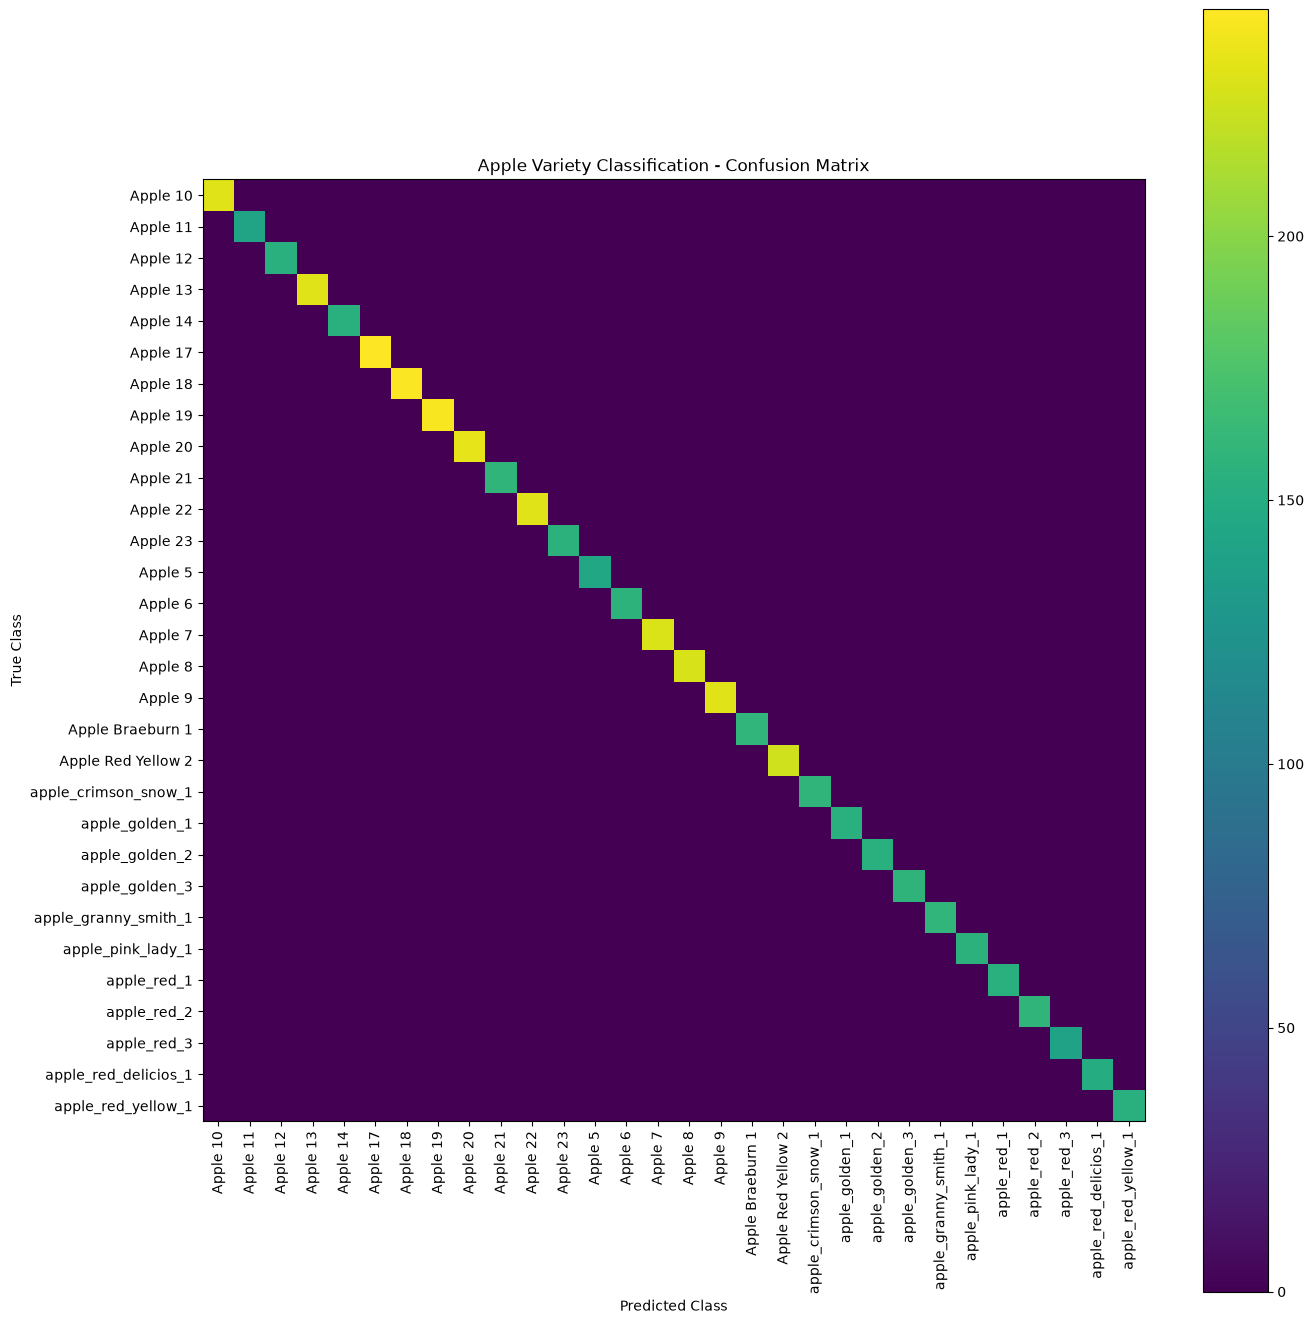

In [54]:
plt.figure(figsize=(14, 14))

plt.imshow(cm)

plt.title("Apple Variety Classification - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.colorbar()

plt.xticks(
    range(len(test_ds.classes)),
    test_ds.classes,
    rotation=90
)

plt.yticks(
    range(len(test_ds.classes)),
    test_ds.classes
)

plt.tight_layout()
plt.show()

In [55]:
model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        wrong = predicted != labels

        for image, label, prediction in zip(
            images[wrong],
            labels[wrong],
            predicted[wrong]
        ):
            wrong_images.append(image.cpu())
            wrong_labels.append(label.cpu().item())
            wrong_predictions.append(prediction.cpu().item())

In [56]:
print("Wrong validation predictions:", len(wrong_images))

Wrong validation predictions: 387


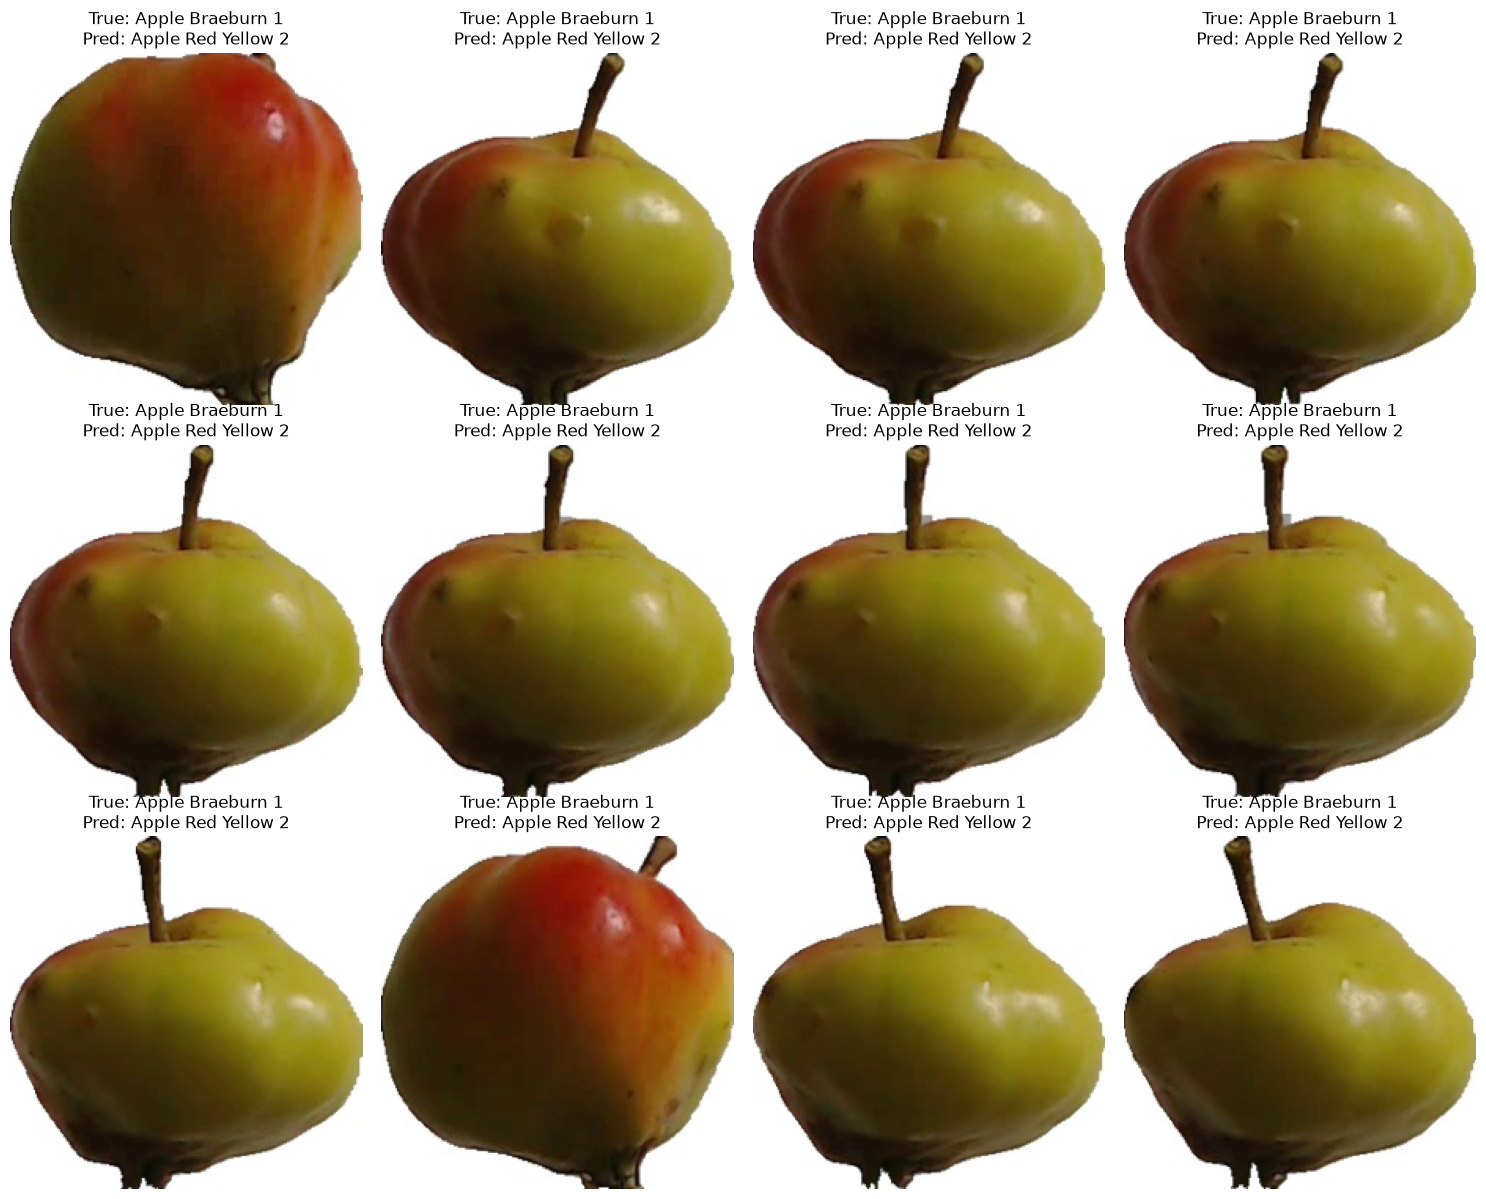

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

for i in range(min(12, len(wrong_images))):

    image = wrong_images[i].permute(1, 2, 0)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(
        f"True: {test_ds.classes[wrong_labels[i]]}\n"
        f"Pred: {test_ds.classes[wrong_predictions[i]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [59]:
from sklearn.metrics import confusion_matrix

val_true = []
val_pred = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        val_true.extend(labels.numpy())
        val_pred.extend(predicted.cpu().numpy())

val_cm = confusion_matrix(val_true, val_pred)

print("Validation errors:", (val_cm.sum() - val_cm.diagonal().sum()))

Validation errors: 387


In [61]:
import numpy as np

confusions = []

for i in range(len(val_ds.classes)):
    for j in range(len(val_ds.classes)):

        if i != j and val_cm[i, j] > 0:
            confusions.append((
                val_cm[i, j],
                val_ds.classes[i],
                val_ds.classes[j]
            ))

confusions.sort(reverse=True)

for count, true_class, predicted_class in confusions[:15]:
    print(
        f"{count:3d} | "
        f"True: {true_class} → "
        f"Pred: {predicted_class}"
    )

227 | True: Apple Red Yellow 2 → Pred: apple_braeburn_1
160 | True: apple_braeburn_1 → Pred: Apple Red Yellow 2


In [14]:
class AppleCNNImproved(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
            
        )
        
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 30)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x
        
        

In [15]:
model_improved = AppleCNNImproved()

print(model_improved)

print(
    "Parameters:",
    sum(p.numel() for p in model_improved.parameters())
)

AppleCNNImproved(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=30, bias=True)
  )
)
Parameters: 133982


In [19]:
criterion_improved = nn.CrossEntropyLoss()

optimizer_improved = torch.optim.Adam(
    model_improved.parameters(),
    lr=0.001
)

In [20]:
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    
    model_improved.train()
    
    running_loss = 0.0
    
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer_improved.zero_grad()
        
        outputs = model_improved(images)
        
        loss = criterion_improved(outputs, labels)
        
        loss.backward()
        
        optimizer_improved.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Loss: {epoch_loss:.4f}"
    )
        

Epoch [1/10] Loss: 2.2064
Epoch [2/10] Loss: 0.8313
Epoch [3/10] Loss: 0.3937
Epoch [4/10] Loss: 0.2442
Epoch [5/10] Loss: 0.1852
Epoch [6/10] Loss: 0.1436
Epoch [7/10] Loss: 0.1175
Epoch [8/10] Loss: 0.0805
Epoch [9/10] Loss: 0.1085
Epoch [10/10] Loss: 0.0711


In [21]:
model_improved.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_improved(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy_improved = 100 * correct / total

print(f"Improved Validation Accuracy: {val_accuracy_improved:.2f}%")


Improved Validation Accuracy: 91.89%


In [22]:
model_improved.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_improved(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 98.76%


In [23]:
from sklearn.metrics import classification_report

model_improved.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_improved(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())

In [24]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_ds.classes
    )
)

                      precision    recall  f1-score   support

            Apple 10       0.98      0.89      0.93       231
            Apple 11       0.99      0.99      0.99       142
            Apple 12       0.93      0.99      0.96       154
            Apple 13       1.00      1.00      1.00       231
            Apple 14       1.00      1.00      1.00       154
            Apple 17       0.96      1.00      0.98       243
            Apple 18       1.00      0.96      0.98       242
            Apple 19       1.00      1.00      1.00       241
            Apple 20       1.00      1.00      1.00       234
            Apple 21       1.00      1.00      1.00       159
            Apple 22       1.00      0.95      0.97       231
            Apple 23       1.00      1.00      1.00       156
             Apple 5       1.00      1.00      1.00       146
             Apple 6       1.00      1.00      1.00       157
             Apple 7       1.00      1.00      1.00       229
       